# 06 — `src/models/rule_baseline.py`: The Sanity-Floor Baseline

CLAUDE.md is explicit about the build order: **this model must exist before XGBoost or the LSTM are trusted.** The reasoning is worth internalizing, because it's a general ML practice, not just a rule for this project: if a sophisticated model can't clearly beat a handful of simple if/else rules written directly from clinical knowledge, that's a red flag about your *features or labels*, not evidence that the ML approach is wrong. Complex models are good at finding patterns — but they can't find a signal that isn't there, and they can also overfit to noise in a way that looks like "learning" but doesn't generalize. A baseline this simple has nowhere to hide: if it does well, the raw signal is genuinely strong; if a fancier model doesn't clearly beat it, something upstream is probably broken.

This model is deliberately dumb: no learned weights, no training, just a decision tree written by hand from `docs/lls_mapping.md`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.models import rule_baseline
from src.config import PROCESSED_DIR, SEVERITY_TIERS, HR_NORMAL_RANGE

## The decision logic, read top to bottom

```python
def classify_row(spo2_delta, hr, spo2_trend_5min):
    hr_normal_mid = sum(HR_NORMAL_RANGE) / 2
    hr_elevation = hr - hr_normal_mid
    steep_negative_trend = spo2_trend_5min < -0.15

    if spo2_delta >= 16 or (spo2_delta >= 10 and steep_negative_trend):
        if spo2_delta >= 20 and hr_elevation >= 35:
            return SEVERITY_INDEX["HACE risk"]
        return SEVERITY_INDEX["HAPE risk"]
    if spo2_delta >= 8 or hr_elevation >= 20:
        return SEVERITY_INDEX["Severe AMS"]
    if spo2_delta >= 4 or hr_elevation >= 10:
        return SEVERITY_INDEX["Mild AMS"]
    return SEVERITY_INDEX["Normal"]
```

This reads almost exactly like a clinician's mental checklist, cascading from most-severe to least-severe:

1. **Very large SpO2 deviation (>=16%), OR a moderately large deviation (>=10%) combined with a steep worsening trend** → HAPE/HACE risk territory. The `OR` with the trend check exists because `docs/lls_mapping.md` notes that early HAPE can desaturate *fast* — the trend can be the tell before the absolute number looks catastrophic.
2. Within that danger zone, an even more extreme deviation (>=20%) *and* a strongly elevated heart rate (>=35 bpm above normal) escalates from HAPE risk to HACE risk — modeling HACE as the more decompensated end of the same spectrum.
3. Otherwise, cascading down through Severe AMS (>=8% deviation or >=20bpm elevation), Mild AMS (>=4% or >=10bpm), and finally Normal.

**One deliberate limitation, called out directly in the code comment:** the rule baseline computes `hr_elevation` against the *population-normal* midpoint (`sum(HR_NORMAL_RANGE)/2`), not a specific subject's individual resting heart rate — because unlike the ML models (which implicitly learn individual patterns from training data), a hand-written rule has no memory of any specific patient's baseline. This keeps the comparison to XGBoost/LSTM fair: those models aren't cheating by secretly having access to information the baseline doesn't.

In [2]:
hr_mid = sum(HR_NORMAL_RANGE) / 2
print(f"HR_NORMAL_RANGE = {HR_NORMAL_RANGE}, midpoint used as 'normal' reference = {hr_mid}")

# Walk through a few illustrative cases by hand
examples = [
    dict(spo2_delta=1.0,  hr=75,  spo2_trend_5min=0.0,   note="near-normal reading"),
    dict(spo2_delta=6.0,  hr=85,  spo2_trend_5min=-0.02, note="mild deviation"),
    dict(spo2_delta=11.0, hr=95,  spo2_trend_5min=-0.01, note="severe deviation, stable trend"),
    dict(spo2_delta=11.0, hr=95,  spo2_trend_5min=-0.20, note="same deviation, but STEEP negative trend"),
    dict(spo2_delta=22.0, hr=120, spo2_trend_5min=-0.10, note="extreme deviation + high HR"),
]
for ex in examples:
    tier_idx = rule_baseline.classify_row(ex["spo2_delta"], ex["hr"], ex["spo2_trend_5min"])
    print(f"{ex['note']:42s} -> {SEVERITY_TIERS[tier_idx]}")

HR_NORMAL_RANGE = (50, 100), midpoint used as 'normal' reference = 75.0
near-normal reading                        -> Normal
mild deviation                             -> Mild AMS
severe deviation, stable trend             -> Severe AMS
same deviation, but STEEP negative trend   -> HAPE risk
extreme deviation + high HR                -> HACE risk


Notice rows 3 and 4 have the *identical* `spo2_delta` (11.0) — the only difference is the trend (stable vs. steep negative). Row 3 lands at Severe AMS, row 4 jumps to HAPE risk. That's the trend-aware branch in action: the rule baseline can catch a rapidly-worsening case *before* the absolute deviation alone would flag it.

## `predict()`: applying the rule across a whole DataFrame

```python
def predict(df):
    required = {"spo2_delta", "hr", "spo2_trend_5min"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(...)
    return df.apply(lambda row: classify_row(...), axis=1).to_numpy()
```

Two things worth noting:
- It **validates required columns up front** and raises a clear error naming exactly what's missing, rather than letting a `KeyError` happen deep inside `classify_row` with a confusing traceback. This matters because `predict()` assumes the DataFrame has already been through `feature_engineering.engineer_features()` — if you pass in raw, un-engineered data, you get a helpful message instead of a cryptic crash.
- It uses `df.apply(..., axis=1)`, which (unlike the vectorized trend calculation in `feature_engineering.py`) genuinely does call `classify_row` once per row. That's fine here — this baseline is meant to be a simple, readable reference implementation, not a performance-critical path (it doesn't run in a training loop the way feature engineering does).

In [3]:
try:
    rule_baseline.predict(pd.DataFrame({"spo2": [90, 85]}))  # missing required columns
except ValueError as e:
    print("Got the expected clear error:")
    print(e)

Got the expected clear error:
rule_baseline.predict() requires columns {'spo2_delta', 'spo2_trend_5min', 'hr'}, missing {'spo2_delta', 'spo2_trend_5min', 'hr'}. Run src.data.feature_engineering.engineer_features first.


## Running it on the real test set

Let's load the actual held-out test data (produced by the `feature_engineering` notebook's pipeline) and see how the baseline actually performs.

In [4]:
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")
y_true = test_df["severity_index"].to_numpy()
y_pred = rule_baseline.predict(test_df)

from src.models.metrics import evaluate, print_report
result = evaluate(y_true, y_pred, model_name="Rule-Based Baseline (test set)")
print_report(result)


  Rule-Based Baseline (test set)
  Precision (macro):       0.3490
  Recall (macro):          0.2870
  F1 (macro):              0.2845
  Mean Abs Tier Error:     0.8189  (0 = perfect)
  Under-triage rate:       0.3088  (predicted too mild)

  Confusion matrix (rows=actual, cols=predicted):
            Normal  Mild AMS  Severe AMS  HAPE risk  HACE risk
Normal      128708     51082       20010          0          0
Mild AMS     36715     19086        3599          0          0
Severe AMS   21283     10299       17018          0          0
HAPE risk     8814      3914        5893       2439        540
HACE risk    10659      2431        4151       4225        134



## Reading the confusion matrix

The confusion matrix's rows are the *actual* tier, columns are what the baseline *predicted*. A perfect model would have all its mass on the diagonal. What you'll typically see here:

- The baseline correctly identifies a good chunk of Normal and Mild AMS cases (these have clearer, less overlapping signal ranges).
- It struggles more with Severe AMS vs Mild AMS (the ranges in `docs/lls_mapping.md` intentionally overlap somewhat at the boundaries, since real physiology doesn't have hard cutoffs either).
- It's noticeably weaker at distinguishing HAPE risk from HACE risk specifically — both occupy the same "large deviation" region of the rule tree, and the HACE-specific sub-condition (`spo2_delta >= 20 and hr_elevation >= 35`) is a fairly narrow slice, so many true HACE cases get called HAPE risk instead. This is expected and okay: they're adjacent, both-dangerous tiers, and this exact weakness is one of the things we're hoping XGBoost's *learned* thresholds can improve on — which is precisely the comparison made in the `predict_severity` notebook.

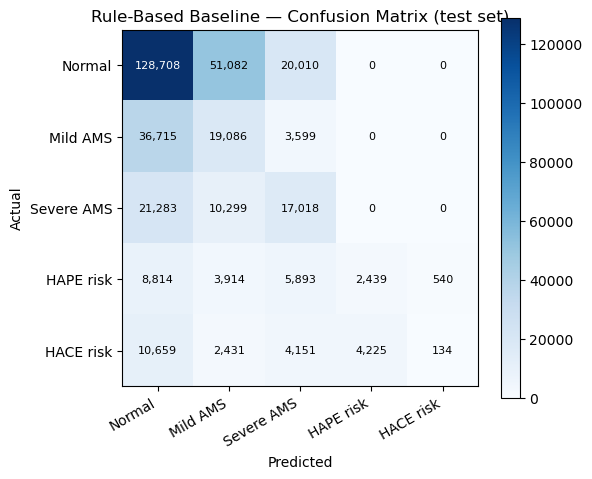

In [5]:
# Plain matplotlib heatmap (no seaborn dependency needed)
cm = result["confusion_matrix"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(SEVERITY_TIERS)), SEVERITY_TIERS, rotation=30, ha="right")
ax.set_yticks(range(len(SEVERITY_TIERS)), SEVERITY_TIERS)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Rule-Based Baseline — Confusion Matrix (test set)")
for i in range(len(SEVERITY_TIERS)):
    for j in range(len(SEVERITY_TIERS)):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
fig.colorbar(im)
fig.tight_layout()
plt.show()

## Summary

The rule-based baseline exists as a floor to beat, not a model we intend to ship. It's built entirely from `docs/lls_mapping.md`'s written clinical reasoning, with no training and no learned parameters — which makes it a genuinely fair, principled sanity check. If you look back at the model comparison results (in `predict_severity` notebook / `01_data_exploration.ipynb`), XGBoost beats this baseline on every metric, particularly mean-absolute-tier-error — confirming there's real learnable signal in the engineered features beyond what a hand-written rule tree captures.

**Next notebook:** `07_metrics.ipynb` — the shared evaluation code every model (baseline, XGBoost, LSTM) is scored with identically.